# Notebook 4 – PCA: Hochdimensionale Daten visualisieren (Ziffern)
**Maschinelles Lernen mit Python · Kapitel 12: Dimensionsreduktion**  

---

## 🎯 Lernziele dieses Notebooks

Nach Bearbeitung dieses Notebooks können Sie:
- PCA als Werkzeug zur **Visualisierung hochdimensionaler Daten** einsetzen (64D → 2D)
- einen **Kernel Density Estimate (KDE)-Plot** erstellen und interpretieren
- anhand des kumulierten Varianzplots bestimmen, wie viele Komponenten für **90 % Varianz** nötig sind
- die **Grenzen von 2D-PCA** bei hochdimensionalen Datensätzen beschreiben

---

## 📖 Kontext

Der `load_digits`-Datensatz enthält 1.797 handgeschriebene Ziffern (0–9) als 8×8-Pixel-Bilder. Jedes Bild hat **64 Features** (Pixelwerte). Wir reduzieren auf **2D** zur Visualisierung – und analysieren, was dabei verloren geht.


> KDE-Plot zeigt, welche Ziffernpaare im 2D-PCA-Raum nahe beieinander liegen.

---
## Schritt 1: Zifferndatensatz laden und erkunden

load_digits Datensatz:
  Bilder:     (1797, 8, 8)  → 1797 Bilder, je 8×8 Pixel
  Datenmatrix: (1797, 64)  → 1797 Zeilen (Bilder), 64 Spalten (Pixelwerte = Features!)
  Klassen:    [0 1 2 3 4 5 6 7 8 9]
  Verteilung: [178 182 177 183 181 182 181 179 174 180]


/tmp/ipykernel_12247/456261232.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


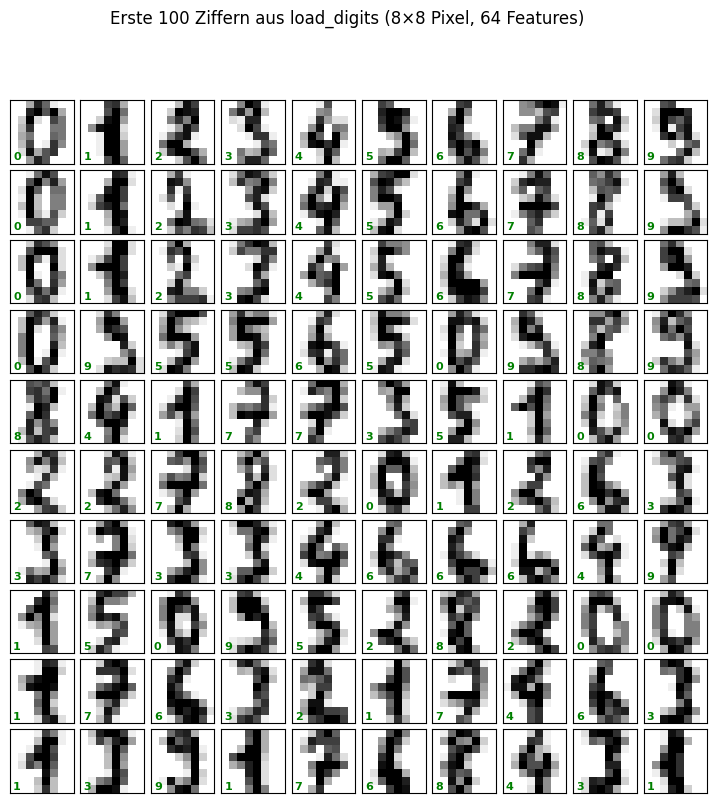

In [1]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
import numpy as np

digits = load_digits()

print("load_digits Datensatz:")
print(f"  Bilder:     {digits.images.shape}  → {digits.images.shape[0]} Bilder, je {digits.images.shape[1]}×{digits.images.shape[2]} Pixel")
print(f"  Datenmatrix: {digits.data.shape}  → {digits.data.shape[0]} Zeilen (Bilder), {digits.data.shape[1]} Spalten (Pixelwerte = Features!)")
print(f"  Klassen:    {np.unique(digits.target)}")
print(f"  Verteilung: {np.bincount(digits.target)}")

# Erste 100 Bilder anzeigen
fig, axes = plt.subplots(10, 10, figsize=(9, 9),
                         subplot_kw={'xticks': [], 'yticks': []},
                         gridspec_kw=dict(hspace=0.1, wspace=0.1))

for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray_r', interpolation='nearest')
    ax.text(0.05, 0.05, str(digits.target[i]),
            transform=ax.transAxes, color='green', fontsize=8, fontweight='bold')

plt.suptitle('Erste 100 Ziffern aus load_digits (8×8 Pixel, 64 Features)', fontsize=12)
plt.tight_layout()
plt.show()

---
## Schritt 2: PCA – von 64D auf 2D

In [2]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
projected = pca.fit_transform(digits.data)

print(f"Original:     {digits.data.shape}  (64 Features pro Bild)")
print(f"Nach PCA:     {projected.shape}  (2 Hauptkomponenten)")
print()
print(f"Erklärte Varianz:")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"  PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"  Summe: {np.sum(pca.explained_variance_ratio_)*100:.2f}%")
print()
print("⚠️  Hinweis: Nur ~28% der Varianz werden erfasst – starker Informationsverlust!")
print("   Dennoch kann PCA noch strukturelle Muster sichtbar machen.")

Original:     (1797, 64)  (64 Features pro Bild)
Nach PCA:     (1797, 2)  (2 Hauptkomponenten)

Erklärte Varianz:
  PC1: 14.89%
  PC2: 13.62%
  Summe: 28.51%

⚠️  Hinweis: Nur ~28% der Varianz werden erfasst – starker Informationsverlust!
   Dennoch kann PCA noch strukturelle Muster sichtbar machen.


---
## Schritt 3: KDE-Plot – Dichteverteilungen im 2D-PCA-Raum

Ein **Kernel Density Estimate (KDE)**-Plot zeigt, wo die Punkte einer Klasse im 2D-Raum konzentriert sind – als Wahrscheinlichkeitsdichte.

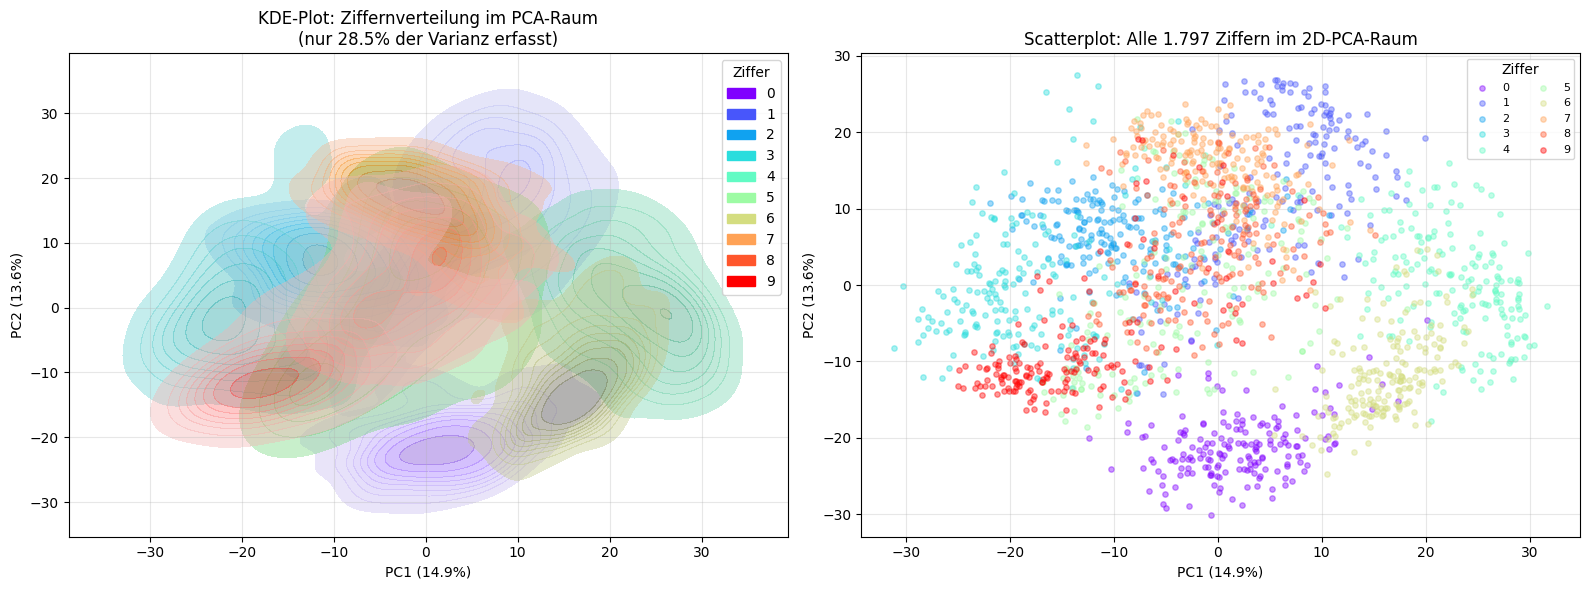

🔍 Beobachtung: Welche Ziffern liegen nahe beieinander?
   → Ziffern mit ähnlicher Pixelstruktur haben ähnliche PC1/PC2-Werte
   Beispiel: 3 und 8 überlappen oft (beide haben ähnliche Kurvenformen)


In [3]:
import seaborn as sns
import pandas as pd

df_projected = pd.DataFrame(projected, columns=['Hauptkomponente_1', 'Hauptkomponente_2'])
df_projected['Ziffer'] = digits.target

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: KDE-Dichteplot ---
sns.kdeplot(
    data=df_projected,
    x='Hauptkomponente_1',
    y='Hauptkomponente_2',
    hue='Ziffer',
    fill=True,
    palette='rainbow',
    alpha=0.4,
    ax=axes[0]
)
axes[0].set_title(
    f'KDE-Plot: Ziffernverteilung im PCA-Raum\n'
    f'(nur {np.sum(pca.explained_variance_ratio_)*100:.1f}% der Varianz erfasst)',
    fontsize=12
)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Scatter-Plot mit Ziffernlabels ---
colors = plt.cm.rainbow(np.linspace(0, 1, 10))
for digit, color in zip(range(10), colors):
    mask = digits.target == digit
    axes[1].scatter(
        projected[mask, 0], projected[mask, 1],
        color=color, alpha=0.4, s=15, label=str(digit)
    )

axes[1].set_title('Scatterplot: Alle 1.797 Ziffern im 2D-PCA-Raum', fontsize=12)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend(title='Ziffer', fontsize=8, ncol=2, loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("🔍 Beobachtung: Welche Ziffern liegen nahe beieinander?")
print("   → Ziffern mit ähnlicher Pixelstruktur haben ähnliche PC1/PC2-Werte")
print("   Beispiel: 3 und 8 überlappen oft (beide haben ähnliche Kurvenformen)")

---
## Schritt 4: Kumulierter Varianzplot – wie viele Komponenten für 90 %?

Die 2D-Projektion war für Visualisierung gut – aber wie viele Komponenten brauchen wir, um **90 % der Varianz** zu erhalten?

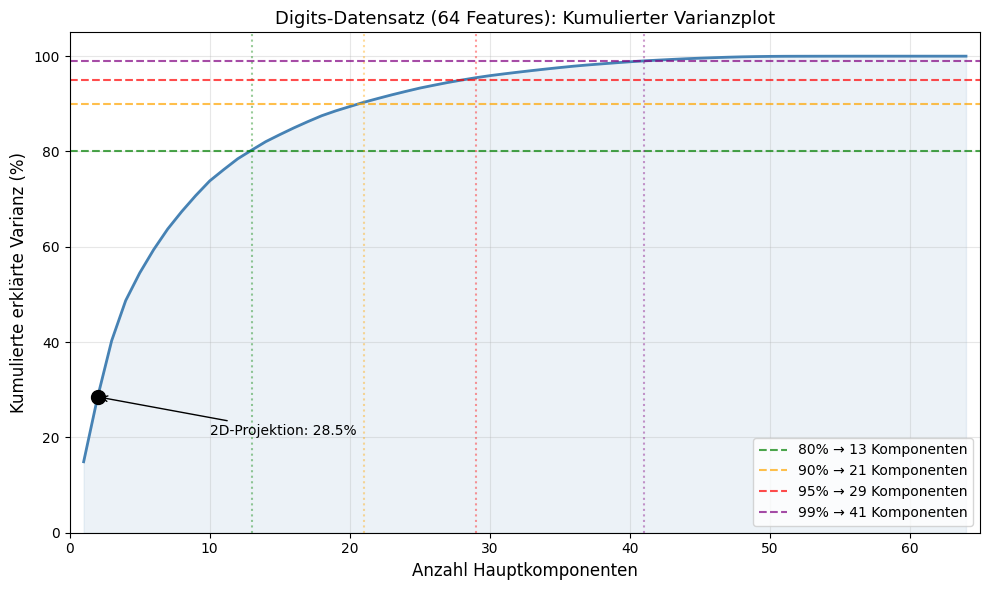

Ergebnisse:
  80% Varianz → 13 Hauptkomponenten nötig
  90% Varianz → 21 Hauptkomponenten nötig
  95% Varianz → 29 Hauptkomponenten nötig
  99% Varianz → 41 Hauptkomponenten nötig

  2D-Projektion erklärt nur: 28.5% der Varianz
  → Starker Informationsverlust, aber für Visualisierung akzeptabel!


In [4]:
pca_full = PCA().fit(digits.data)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Schwellwerte bestimmen
schwellen = {80: None, 90: None, 95: None, 99: None}
for s in schwellen:
    schwellen[s] = np.argmax(cumulative_variance >= s/100) + 1

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1),
         cumulative_variance * 100, 'steelblue', linewidth=2)

# Schwellwert-Linien einzeichnen
farben_schwellen = {'80': 'green', '90': 'orange', '95': 'red', '99': 'purple'}
for s, n in schwellen.items():
    plt.axhline(y=s, color=farben_schwellen[str(s)], linestyle='--', alpha=0.7,
                label=f'{s}% → {n} Komponenten')
    plt.axvline(x=n, color=farben_schwellen[str(s)], linestyle=':', alpha=0.4)

# 2D-Projektion markieren
plt.scatter([2], [cumulative_variance[1] * 100], color='black', s=100, zorder=5)
plt.annotate(
    f'2D-Projektion: {cumulative_variance[1]*100:.1f}%',
    xy=(2, cumulative_variance[1] * 100),
    xytext=(10, cumulative_variance[1]*100 - 8),
    fontsize=10,
    arrowprops=dict(arrowstyle='->', color='black')
)

plt.fill_between(range(1, len(cumulative_variance) + 1),
                 cumulative_variance * 100, alpha=0.1, color='steelblue')
plt.xlabel('Anzahl Hauptkomponenten', fontsize=12)
plt.ylabel('Kumulierte erklärte Varianz (%)', fontsize=12)
plt.title('Digits-Datensatz (64 Features): Kumulierter Varianzplot', fontsize=13)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim(0, 65)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

print("Ergebnisse:")
for s, n in schwellen.items():
    print(f"  {s}% Varianz → {n:2d} Hauptkomponenten nötig")
print(f"\n  2D-Projektion erklärt nur: {cumulative_variance[1]*100:.1f}% der Varianz")
print(f"  → Starker Informationsverlust, aber für Visualisierung akzeptabel!")

---
## 📝 Lernauftrag

**Aufgabe 1 – Ziffernpaare identifizieren:**  
Schauen Sie sich den KDE-Plot an. Welche zwei Ziffern überlappen im 2D-PCA-Raum am stärksten? Warum könnte das so sein? (Hinweis: Betrachten Sie die Pixelstruktur dieser Ziffern.)

**Aufgabe 2 – 90%-Varianz mit PCA:**  
Verwenden Sie `PCA(n_components=0.90)` und prüfen Sie mit `pca.n_components_`, wie viele Komponenten scikit-learn automatisch gewählt hat. Stimmt das mit dem Varianzplot überein?

**Aufgabe 3 – Visualisierung mit mehr Komponenten:**  
Reduzieren Sie auf **3 Dimensionen** statt 2 und erstellen Sie einen 3D-Scatterplot (`fig.add_subplot(projection='3d')`). Verbessert sich die Klassenseparation sichtbar?

In [5]:
# Aufgabe 2: Automatische 90%-Komponentenwahl



In [6]:
# Aufgabe 3: 3D-Scatterplot (optional)

